# 02 PD Modeling

Phase 2 builds a baseline probability of default model using the Phase 1 modeling sample. This notebook does not build IFRS 9 staging, Expected Credit Loss calculations, or dashboard logic.

## Project Context

The Credit Risk and IFRS 9 Expected Credit Loss Engine is a finance and risk analytics portfolio project. Phase 1 prepared `data/processed/modeling_sample.csv`; Phase 2 uses that file to train and evaluate a simple, interpretable PD model.

## Modeling Objective

Train a baseline logistic regression classifier that estimates the probability that a loan record belongs to the default class. The output `pd_score` will be used as an input candidate for the Phase 3 ECL engine.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, MODEL_DIR, OUTPUTS_DIR, PROCESSED_DATA_DIR
from src.features import build_feature_matrix, clean_feature_values, identify_feature_types
from src.modeling import (
    build_logistic_regression_pipeline,
    evaluate_binary_classifier,
    generate_pd_scores,
    save_model,
    split_train_test,
    train_model,
)
from src.visualization import (
    plot_confusion_matrix,
    plot_default_rate_by_score_band,
    plot_pd_score_distribution,
    plot_roc_curve,
    plot_top_coefficients,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / "predictions").mkdir(parents=True, exist_ok=True)

## Load Modeling Sample

In [2]:
modeling_sample_path = PROCESSED_DATA_DIR / "modeling_sample.csv"
if not modeling_sample_path.exists():
    raise FileNotFoundError(f"Missing modeling sample: {modeling_sample_path}")

df = pd.read_csv(modeling_sample_path, low_memory=False)
df = clean_feature_values(df)
print(f"Loaded modeling sample: {modeling_sample_path}")
print(f"Shape: {df.shape}")
display(df.head())

Loaded modeling sample: /Users/rovs/Documents/New project 2/projects/credit-risk-ifrs9-ecl-engine/data/processed/modeling_sample.csv
Shape: (50000, 26)


,default_flag,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies
0,0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,Individual,1.0,0.0
1,0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,Individual,4.0,0.0
2,0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,Aug-2000,695.0,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,Joint App,5.0,0.0
3,0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,0.0,Sep-2008,785.0,789.0,0.0,13.0,0.0,7802.0,11.6,17.0,Individual,1.0,0.0
4,0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,Individual,6.0,0.0


## Target Review

In [3]:
target_col = "default_flag"
if target_col not in df.columns:
    raise KeyError("default_flag is required for PD modeling.")

target_review = df[target_col].value_counts().sort_index().to_frame("row_count")
target_review["share"] = df[target_col].value_counts(normalize=True).sort_index().round(4)
display(target_review)
print(f"Observed default rate: {df[target_col].mean():.2%}")

,row_count,share
default_flag,,
0,40726,0.8145
1,9274,0.1855


Observed default rate: 18.55%


## Feature Selection

Phase 2 uses the available candidate features created in Phase 1. `loan_status` is not used as a feature because it directly defines the target.

In [4]:
X, y = build_feature_matrix(df, target_col=target_col)
numeric_features, categorical_features = identify_feature_types(pd.concat([X, y], axis=1), target_col=target_col)

print(f"Feature matrix shape: {X.shape}")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
display(pd.DataFrame({"feature": X.columns, "dtype": [str(dtype) for dtype in X.dtypes]}))

Feature matrix shape: (50000, 24)
Numeric features (16): ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']
Categorical features (8): ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'application_type']


,feature,dtype
0,loan_amnt,float64
1,term,object
2,int_rate,Float64
3,installment,float64
4,grade,object
5,sub_grade,object
6,emp_length,object
7,home_ownership,object
8,annual_inc,float64
9,verification_status,object


## Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")

Training rows: 40,000
Test rows: 10,000
Train default rate: 18.55%
Test default rate: 18.55%


## Preprocessing Pipeline

Numeric features use median imputation and scaling. Categorical features use most-frequent imputation and one-hot encoding with unknown categories ignored.

In [6]:
model = build_logistic_regression_pipeline(numeric_features, categorical_features)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

## Baseline Logistic Regression Model

In [7]:
model = train_model(model, X_train, y_train)
model_path = save_model(model, MODEL_DIR / "pd_logistic_regression.joblib")
print(f"Saved model artifact: {model_path}")

Saved model artifact: /Users/rovs/Documents/New project 2/projects/credit-risk-ifrs9-ecl-engine/outputs/model/pd_logistic_regression.joblib


## Model Evaluation

,metric,value
0,roc_auc,0.701243
1,accuracy,0.631500
2,precision,0.284503
3,recall,0.651213
4,f1,0.396001


              precision    recall  f1-score   support

           0       0.89      0.63      0.73      8145
           1       0.28      0.65      0.40      1855

    accuracy                           0.63     10000
   macro avg       0.59      0.64      0.57     10000
weighted avg       0.78      0.63      0.67     10000



,pred_0,pred_1
actual_0,5107,3038
actual_1,647,1208


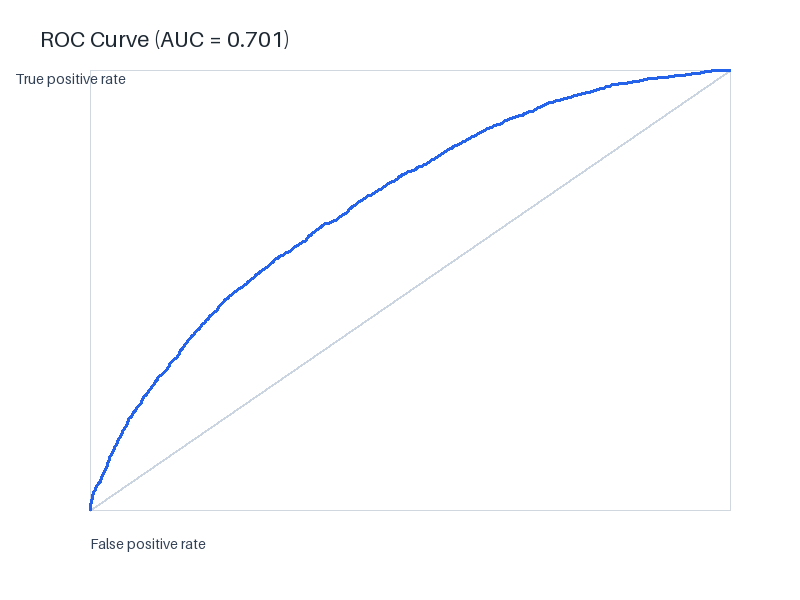

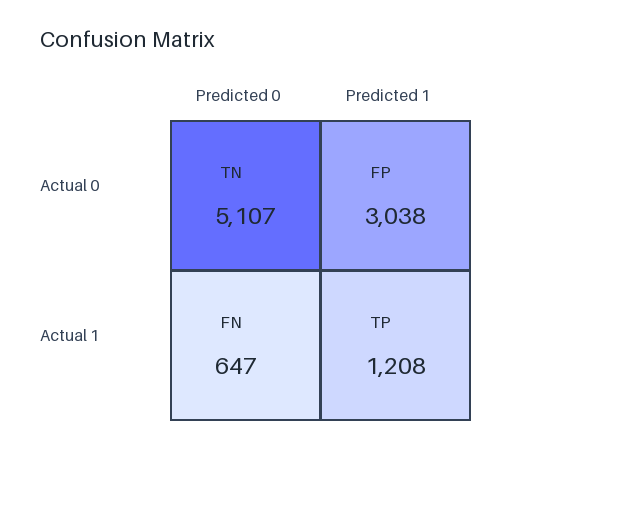

In [8]:
metrics = evaluate_binary_classifier(model, X_test, y_test)
metric_table = pd.DataFrame(
    {
        "metric": ["roc_auc", "accuracy", "precision", "recall", "f1"],
        "value": [metrics["roc_auc"], metrics["accuracy"], metrics["precision"], metrics["recall"], metrics["f1"]],
    }
)
display(metric_table)
print(metrics["classification_report"])
display(pd.DataFrame(metrics["confusion_matrix"], index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"]))

image = plot_roc_curve(metrics["fpr"], metrics["tpr"], metrics["roc_auc"])
image.save(FIGURES_DIR / "pd_roc_curve.png")
display(image)

image = plot_confusion_matrix(metrics["confusion_matrix"])
image.save(FIGURES_DIR / "pd_confusion_matrix.png")
display(image)

## PD Score Generation

PD score banding method: quantile


,row_id,default_flag,pd_score,pd_score_band
0,0,0,0.446690,Medium
1,1,0,0.572757,High
2,2,0,0.259497,Very Low
3,3,0,0.453106,Medium
4,4,0,0.691391,Very High


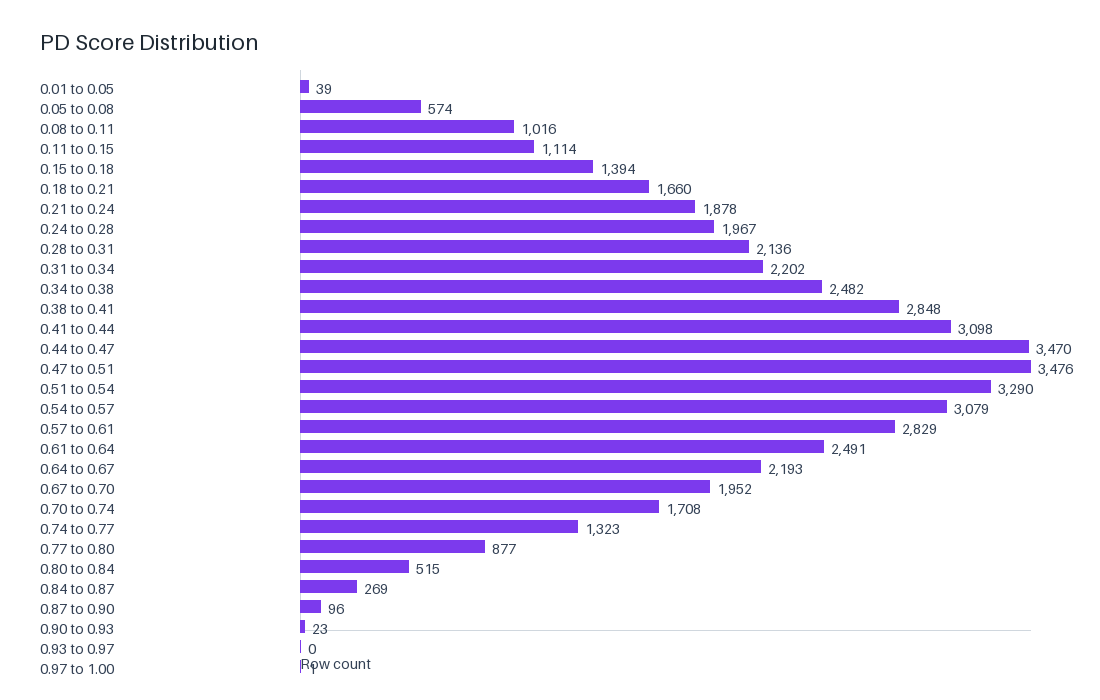

,row_count,observed_default_rate,min_pd_score,max_pd_score
pd_score_band,,,,
Very Low,10000,0.0521,0.015259,0.283361
Low,10000,0.1125,0.283402,0.416441
Medium,10000,0.1682,0.416444,0.513925
High,10000,0.2297,0.513942,0.624798
Very High,10000,0.3649,0.624807,0.999999


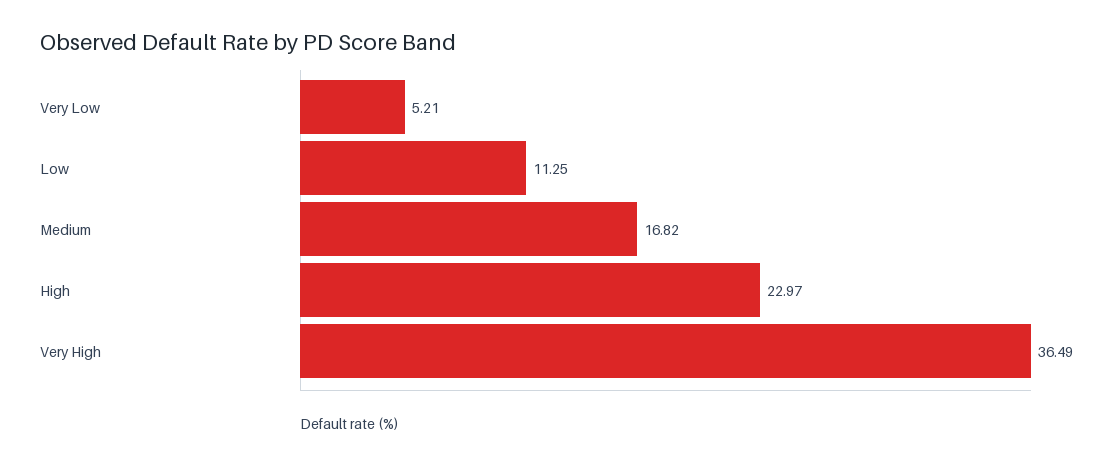

In [9]:
pd_scores = generate_pd_scores(model, X)
predictions = df.copy()
predictions["row_id"] = predictions.index
predictions["pd_score"] = pd_scores

score_band_labels = ["Very Low", "Low", "Medium", "High", "Very High"]
try:
    predictions["pd_score_band"] = pd.qcut(predictions["pd_score"], q=5, labels=score_band_labels)
    banding_method = "quantile"
except ValueError:
    ranked_scores = predictions["pd_score"].rank(method="first")
    predictions["pd_score_band"] = pd.qcut(ranked_scores, q=5, labels=score_band_labels)
    banding_method = "rank-based fallback"

print(f"PD score banding method: {banding_method}")
display(predictions[["row_id", "default_flag", "pd_score", "pd_score_band"]].head())

image = plot_pd_score_distribution(predictions["pd_score"])
image.save(FIGURES_DIR / "pd_score_distribution.png")
display(image)

band_summary = predictions.groupby("pd_score_band", observed=False).agg(
    row_count=("default_flag", "size"),
    observed_default_rate=("default_flag", "mean"),
    min_pd_score=("pd_score", "min"),
    max_pd_score=("pd_score", "max"),
)
band_summary["observed_default_rate"] = band_summary["observed_default_rate"].round(4)
display(band_summary)

image = plot_default_rate_by_score_band(predictions, band_col="pd_score_band", target_col="default_flag")
image.save(FIGURES_DIR / "pd_default_rate_by_score_band.png")
display(image)

## Feature Importance or Coefficient Review

,feature,coefficient,abs_coefficient
25,categorical__sub_grade_A1,-0.439335,0.439335
1,numeric__int_rate,0.405742,0.405742
2,numeric__installment,0.348276,0.348276
18,categorical__grade_A,-0.341924,0.341924
50,categorical__sub_grade_F1,-0.316185,0.316185
0,numeric__loan_amnt,-0.298533,0.298533
83,categorical__purpose_major_purchase,0.286535,0.286535
78,categorical__purpose_car,-0.257258,0.257258
16,categorical__term_36 months,-0.248094,0.248094
24,categorical__grade_G,-0.244717,0.244717


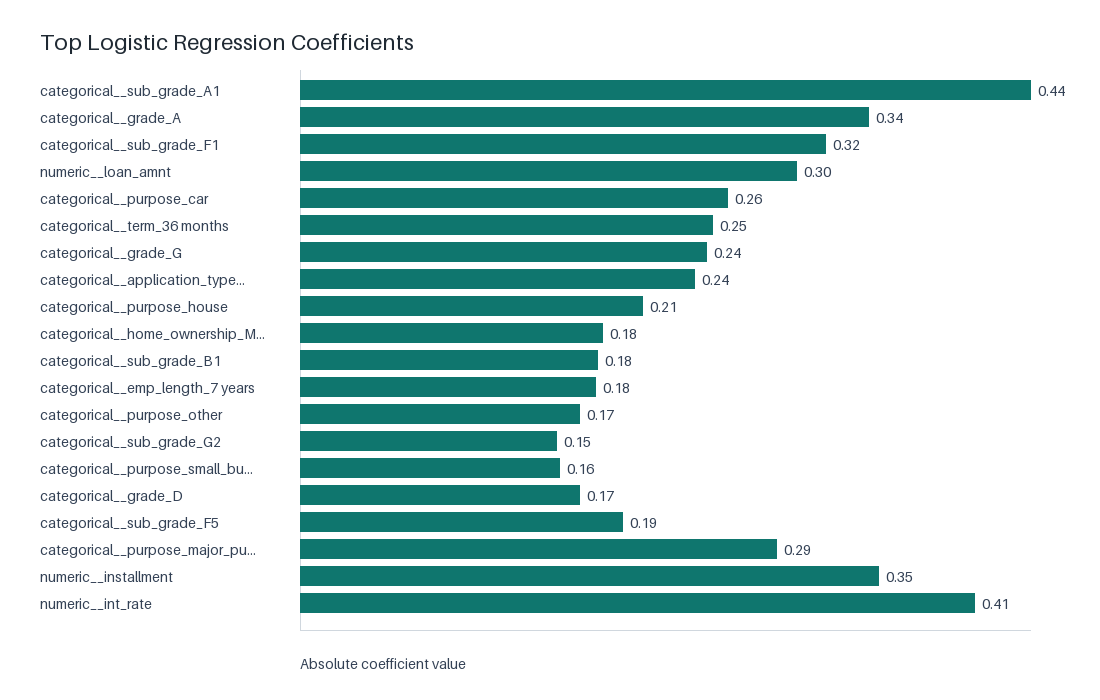

In [10]:
coefficients = pd.DataFrame()
try:
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    coefficient_values = model.named_steps["classifier"].coef_[0]
    coefficients = pd.DataFrame({"feature": feature_names, "coefficient": coefficient_values})
    coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
    display(coefficients.sort_values("abs_coefficient", ascending=False).head(25))

    image = plot_top_coefficients(coefficients, top_n=20)
    image.save(FIGURES_DIR / "pd_top_coefficients.png")
    display(image)
except Exception as exc:
    print(f"Coefficient extraction skipped: {exc}")

## Save PD Predictions

In [11]:
requested_original_fields = [
    "loan_amnt",
    "funded_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "delinq_2yrs",
    "revol_util",
    "total_acc",
    "loan_status",
]
available_original_fields = [column for column in requested_original_fields if column in predictions.columns]
missing_original_fields = [column for column in requested_original_fields if column not in predictions.columns]

prediction_columns = ["row_id", "default_flag", "pd_score", "pd_score_band"] + available_original_fields
pd_predictions = predictions[prediction_columns].copy()
prediction_path = OUTPUTS_DIR / "predictions" / "pd_predictions.csv"
pd_predictions.to_csv(prediction_path, index=False)

print(f"Saved PD predictions: {prediction_path}")
print(f"Prediction file shape: {pd_predictions.shape}")
print(f"Missing requested original fields not present in modeling sample: {missing_original_fields}")
display(pd_predictions.head())

Saved PD predictions: /Users/rovs/Documents/New project 2/projects/credit-risk-ifrs9-ecl-engine/outputs/predictions/pd_predictions.csv
Prediction file shape: (50000, 19)
Missing requested original fields not present in modeling sample: ['funded_amnt', 'loan_status']


,row_id,default_flag,pd_score,pd_score_band,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,revol_util,total_acc
0,0,0,0.446690,Medium,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,29.7,13.0
1,1,0,0.572757,High,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,19.2,38.0
2,2,0,0.259497,Very Low,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,56.2,18.0
3,3,0,0.453106,Medium,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,0.0,11.6,17.0
4,4,0,0.691391,Very High,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,64.5,35.0


## Business Interpretation

In [12]:
print(f"Baseline ROC AUC: {metrics['roc_auc']:.3f}")
print(f"Baseline recall: {metrics['recall']:.3f}")
print(f"Baseline precision: {metrics['precision']:.3f}")
print("The model is a benchmark PD scoring model, not a production credit decision system.")
print("PD score bands provide an ordinal risk segmentation that can feed Phase 3 ECL scenario design.")

Baseline ROC AUC: 0.701
Baseline recall: 0.651
Baseline precision: 0.285
The model is a benchmark PD scoring model, not a production credit decision system.
PD score bands provide an ordinal risk segmentation that can feed Phase 3 ECL scenario design.


## Model Limitations

- This is a baseline logistic regression model only.
- The model is trained on the Phase 1 50,000-row modeling sample, not the full LendingClub file.
- Current accounts are mapped as non-default based on the Phase 1 target definition; this assumption should be reviewed before interpreting lifetime risk.
- No reject inference, macroeconomic adjustment, IFRS 9 staging, LGD, EAD, or ECL calculation is included in Phase 2.
- Coefficients are useful for directional review but require care because categorical variables are one-hot encoded and numeric variables are scaled.

## Outputs for Phase 3 ECL Engine

- `outputs/model/pd_logistic_regression.joblib`
- `outputs/predictions/pd_predictions.csv`
- Phase 2 evaluation figures in `reports/figures/`

These outputs are candidate inputs for Phase 3. Phase 3 still needs explicit LGD, EAD, and ECL assumptions.

## Next Steps

- Confirm target policy assumptions with special attention to current and early delinquency accounts.
- Use the PD prediction file as the starting point for Phase 3 ECL design.
- Define transparent LGD and EAD assumptions.
- Build the ECL calculation notebook without adding IFRS 9 staging complexity until the basic engine is correct.